In [1]:
# building the llm infrastucture
from langchain.chat_models import  init_chat_model
from dotenv import load_dotenv 
import os 
load_dotenv()
llm=init_chat_model("llama-3.3-70b-versatile",model_provider="groq",api_key=os.getenv('GROQ'))


In [46]:
def multiply(a:int,b:int):
    """ this is function which is used to multiply two numbers"""
    return a*b
tools=[multiply]
llmwithtools=llm.bind_tools(tools)

In [47]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition,ToolNode
def assistant(state:MessagesState):
    return {"messages":llmwithtools.invoke(state['messages'])}
graph=StateGraph(MessagesState)
memory=MemorySaver()
graph.add_node('assistants',assistant)
graph.add_node('tools',ToolNode(tools))

graph.add_edge(START,'assistants')

graph.add_conditional_edges("assistants", tools_condition)
graph.add_edge("tools", "assistants")

# ======================
# COMPILE
# ======================

app = graph.compile(interrupt_before=['tools'],checkpointer=memory)

In [62]:
config={
    "configurable":{"thread_id":"testing1"}
}
for chunk in app.stream({"messages":"tell me what i asked earlier"},config=config,stream_mode='messages'):
    print(chunk)


(AIMessageChunk(content='', additional_kwargs={}, response_metadata={'model_provider': 'groq'}, id='lc_run--019e6ad5-3798-7903-bb71-8eca8df87aed', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'thread_id': 'testing1', 'ls_integration': 'langchain_chat_model', 'langgraph_step': 15, 'langgraph_node': 'assistants', 'langgraph_triggers': ('branch:to:assistants',), 'langgraph_path': ('__pregel_pull', 'assistants'), 'langgraph_checkpoint_ns': 'assistants:82941c4a-b3d9-9d4f-ca6c-c9836da9776c', 'checkpoint_ns': 'assistants:82941c4a-b3d9-9d4f-ca6c-c9836da9776c', 'ls_provider': 'groq', 'ls_model_name': 'llama-3.3-70b-versatile', 'ls_model_type': 'chat', 'ls_temperature': 0.7})
(AIMessageChunk(content='You', additional_kwargs={}, response_metadata={'model_provider': 'groq'}, id='lc_run--019e6ad5-3798-7903-bb71-8eca8df87aed', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'thread_id': 'testing1', 'ls_integration': 'langchain_chat_model', 'langgraph_step': 15, 'langgrap

In [58]:
for msg, metadata in app.stream(
    None,
    config=config,
    stream_mode="messages"
):
    print(msg.content)

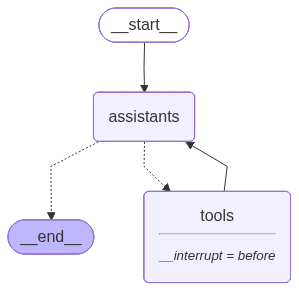

In [53]:
from IPython.display import Image,display 
display(Image(app.get_graph().draw_mermaid_png()))

In [61]:
s=app.get_state(config)
s.next

()